In [1]:
print('hello world!')

hello world!


In [3]:
#checking the exponential addition
1.731e+05 #+ 1.721e+05

173100.0

In [22]:
import pandas as pd
import numpy as np
from sklearn import linear_model 
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('homeprices.csv')

In [7]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,680000
4,4000,5.0,8,725000


In [9]:
import math
median_bedrooms = df.bedrooms.median()
median_bedrooms = math.floor(median_bedrooms)
median_bedrooms

3

In [10]:
df.bedrooms = df.bedrooms.fillna(median_bedrooms)
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,3.0,18,610000
3,3600,3.0,30,680000
4,4000,5.0,8,725000


In [11]:
#Training the model

reg = linear_model.LinearRegression()
reg.fit(df[['area','bedrooms','age']],df.price)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
#Testing the model with test data to see the prediction price value for house 3200sqft, 3 bedrooms, 40 years old
reg.predict([[3200,3,40]])

C:\Users\lenovo\softwares\python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([625925.])

In [13]:
# saving the trained model (so that we don't have to retrain it every time)
import pickle

# Save the trained model to a file
with open('homeprice-model.pkl', 'wb') as f:
    pickle.dump(reg, f)

In [14]:
# Load the saved model from the file
with open('homeprice-model.pkl', 'rb') as f:
    loaded_reg = pickle.load(f)

In [15]:
# # Use the loaded model to predict a price
# Example: 3000 sqft area, 3 bedrooms, 10 years old
predicted_price = loaded_reg.predict([[3000, 3, 10]])
print(predicted_price)

[587075.]


C:\Users\lenovo\softwares\python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


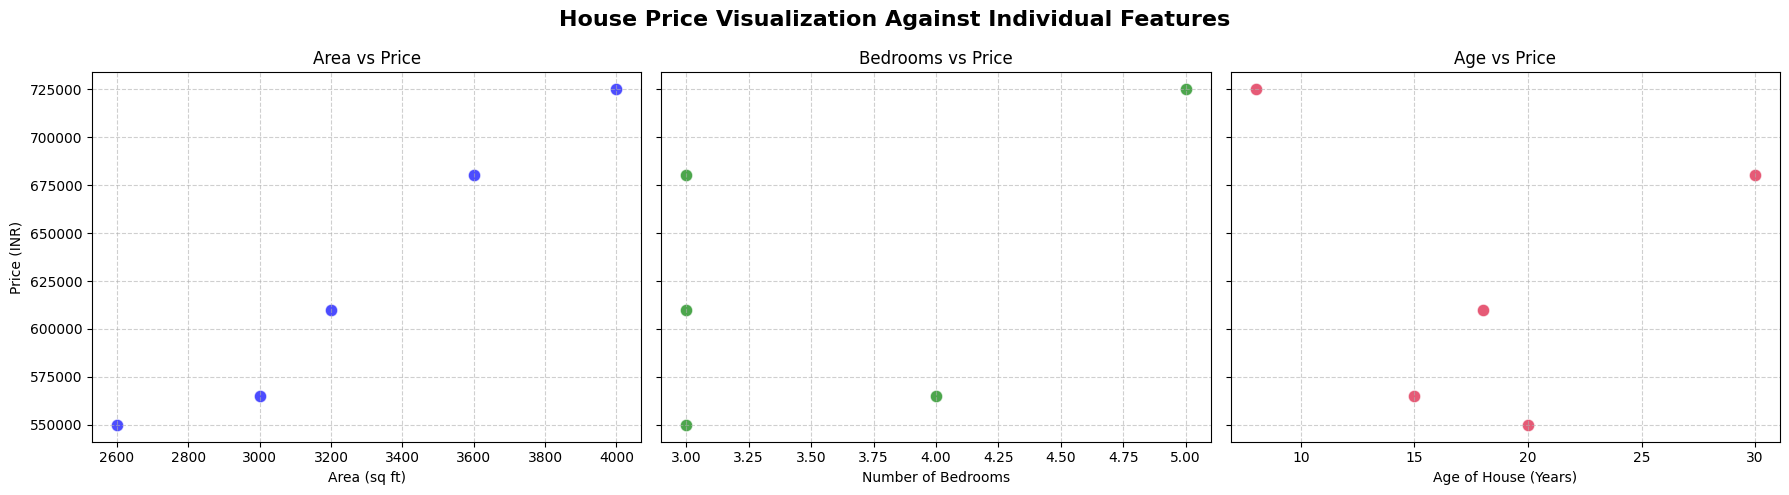

In [17]:
# Let's visualize the data with scatter plot:

# Set up the plotting area (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('House Price Visualization Against Individual Features', fontsize=16, fontweight='bold')

# 1. Scatter plot for Area vs Price
sns.scatterplot(ax=axes[0], data=df, x='area', y='price', color='blue', alpha=0.7, s=80)
axes[0].set_title('Area vs Price', fontsize=12)
axes[0].set_xlabel('Area (sq ft)')
axes[0].set_ylabel('Price (INR)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Scatter plot for Bedrooms vs Price
sns.scatterplot(ax=axes[1], data=df, x='bedrooms', y='price', color='green', alpha=0.7, s=80)
axes[1].set_title('Bedrooms vs Price', fontsize=12)
axes[1].set_xlabel('Number of Bedrooms')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Scatter plot for Age vs Price
sns.scatterplot(ax=axes[2], data=df, x='age', y='price', color='crimson', alpha=0.7, s=80)
axes[2].set_title('Age vs Price', fontsize=12)
axes[2].set_xlabel('Age of House (Years)')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to make sure text labels don't overlap
plt.tight_layout()
plt.show()


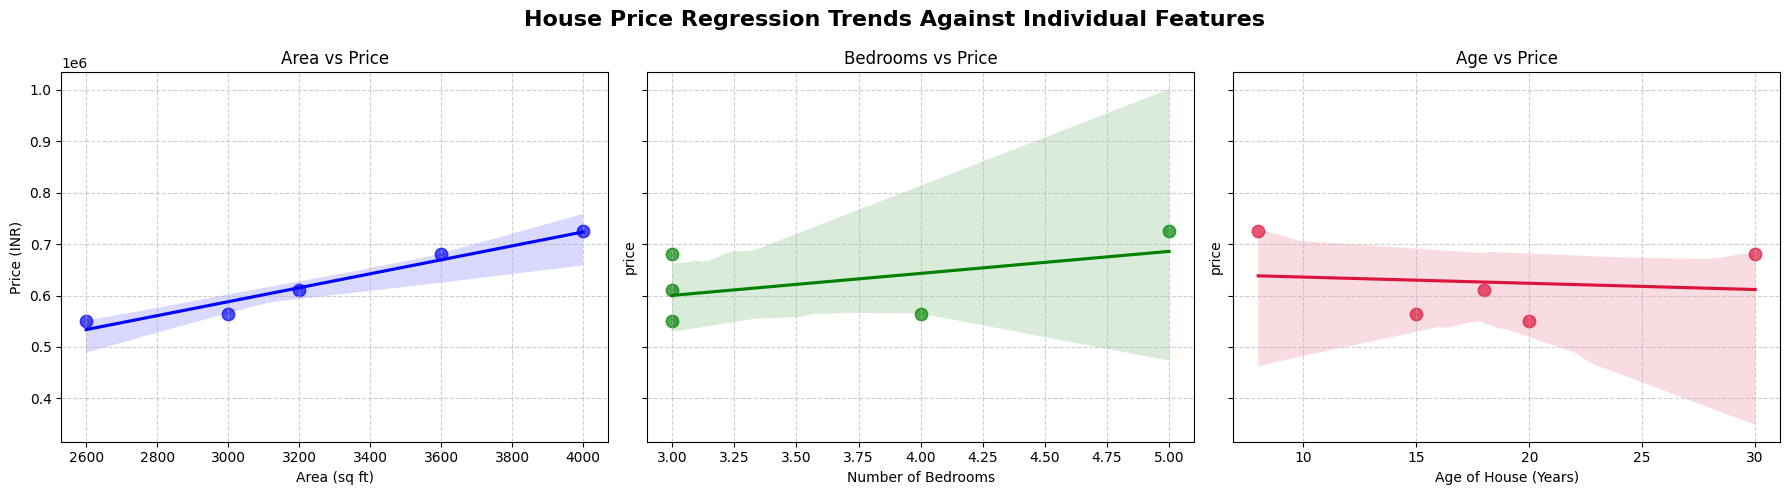

In [20]:
# Visualise for Trend

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('House Price Regression Trends Against Individual Features', fontsize=16, fontweight='bold')

# 1. Regression Plot for Area vs Price
sns.regplot(ax=axes[0], data=df, x='area', y='price', color='blue', 
            scatter_kws={'alpha': 0.7, 's': 80})
axes[0].set_title('Area vs Price', fontsize=12)
axes[0].set_xlabel('Area (sq ft)')
axes[0].set_ylabel('Price (INR)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Regression Plot for Bedrooms vs Price
sns.regplot(ax=axes[1], data=df, x='bedrooms', y='price', color='green', 
            scatter_kws={'alpha': 0.7, 's': 80})
axes[1].set_title('Bedrooms vs Price', fontsize=12)
axes[1].set_xlabel('Number of Bedrooms')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Regression Plot for Age vs Price
sns.regplot(ax=axes[2], data=df, x='age', y='price', color='crimson', 
            scatter_kws={'alpha': 0.7, 's': 80})
axes[2].set_title('Age vs Price', fontsize=12)
axes[2].set_xlabel('Age of House (Years)')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



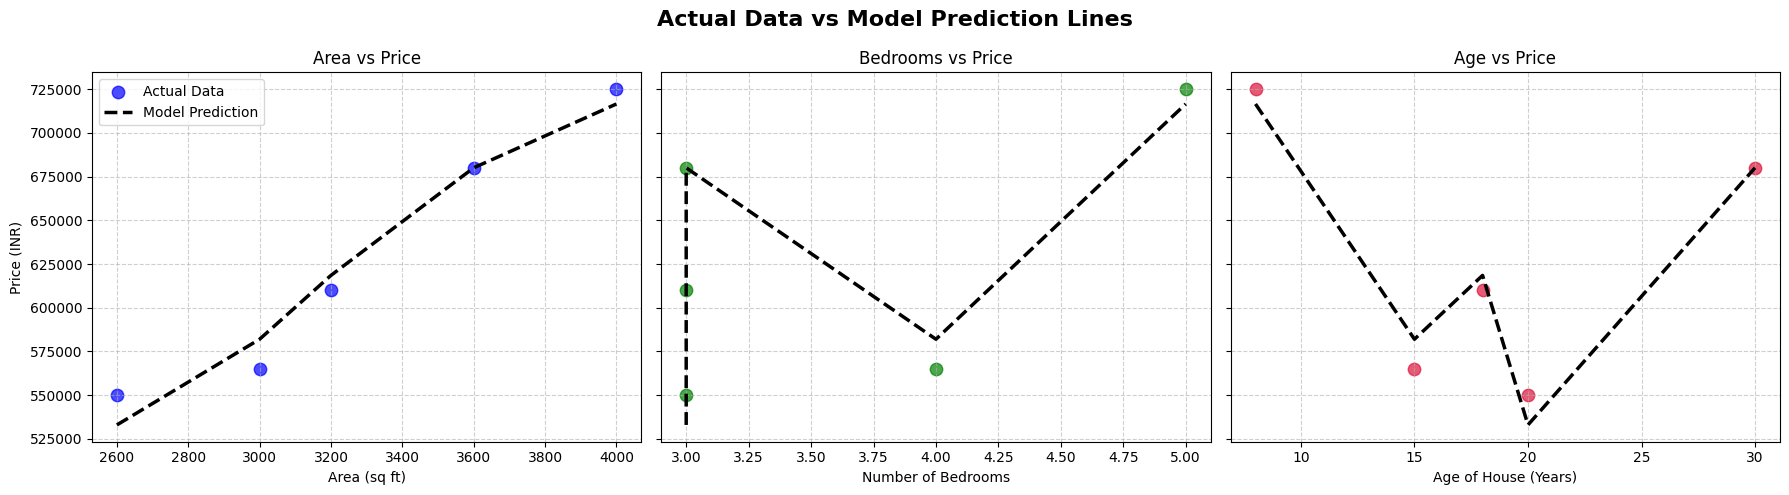

In [21]:
# Let's see the prediction line generated by our multivariate model

# 1. Generate the model's predictions for your existing data points
df['predicted_price'] = reg.predict(df[['area', 'bedrooms', 'age']])

# 2. Set up the plotting area
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Actual Data vs Model Prediction Lines', fontsize=16, fontweight='bold')

# List of features to loop through for cleaner code
features = ['area', 'bedrooms', 'age']
x_labels = ['Area (sq ft)', 'Number of Bedrooms', 'Age of House (Years)']
colors = ['blue', 'green', 'crimson']

for i, feature in enumerate(features):
    # Plot the actual data points as dots
    axes[i].scatter(df[feature], df['price'], color=colors[i], alpha=0.7, s=80, label='Actual Data')
    
    # Sort the values so the prediction line connects smoothly from left to right
    sorted_df = df.sort_values(by=feature)
    
    # Plot your model's actual prediction line
    axes[i].plot(sorted_df[feature], sorted_df['predicted_price'], color='black', linewidth=2.5, linestyle='--', label='Model Prediction')
    
    # Formatting
    axes[i].set_title(f'{feature.capitalize()} vs Price', fontsize=12)
    axes[i].set_xlabel(x_labels[i])
    axes[i].grid(True, linestyle='--', alpha=0.6)
    if i == 0:
        axes[i].set_ylabel('Price (INR)')
        axes[i].legend()

plt.tight_layout()
plt.show()
